In [2]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [8]:
def load_data():
    PROCESSED_DATA_DIR = '../data/processed'
    
    # Load features
    X_train = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, 'X_train_features.csv'))
    X_test = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, 'X_test_features.csv'))
    
    # Load labels
    y_train = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, 'y_train.csv')).values.ravel()
    y_test = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, 'y_test.csv')).values.ravel()
    
    return X_train, X_test, y_train, y_test

# Load the data
print("Loading data...")
X_train, X_test, y_train, y_test = load_data()

Loading data...



Training and evaluating models...

Training Random Forest...

Random Forest Results:
Accuracy: 0.9237

Classification Report:
              precision    recall  f1-score   support

      glioma       0.95      0.74      0.83       300
  meningioma       0.82      0.95      0.88       306
     notumor       0.98      1.00      0.99       405
   pituitary       0.95      0.98      0.96       300

    accuracy                           0.92      1311
   macro avg       0.92      0.92      0.92      1311
weighted avg       0.93      0.92      0.92      1311



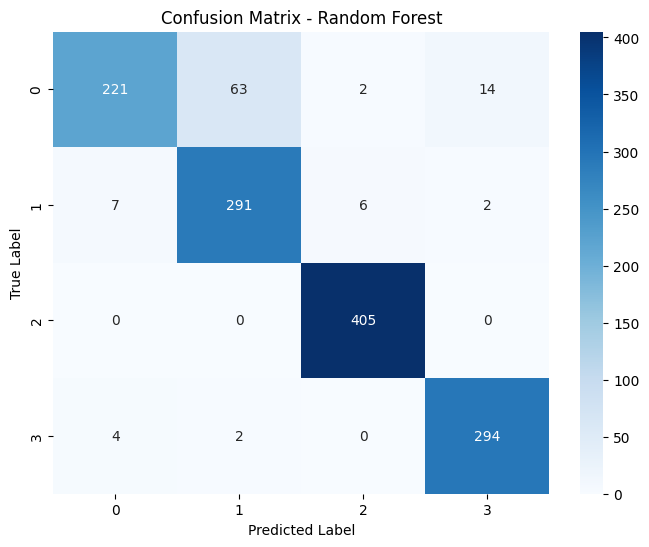


Training Gradient Boosting...

Gradient Boosting Results:
Accuracy: 0.8505

Classification Report:
              precision    recall  f1-score   support

      glioma       0.84      0.69      0.76       300
  meningioma       0.73      0.75      0.74       306
     notumor       0.91      0.98      0.95       405
   pituitary       0.89      0.94      0.91       300

    accuracy                           0.85      1311
   macro avg       0.84      0.84      0.84      1311
weighted avg       0.85      0.85      0.85      1311



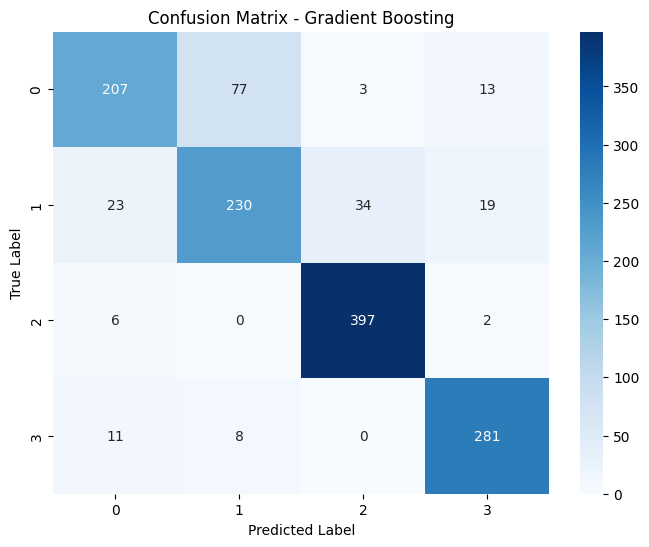


Training SVM...

SVM Results:
Accuracy: 0.7971

Classification Report:
              precision    recall  f1-score   support

      glioma       0.81      0.64      0.72       300
  meningioma       0.66      0.60      0.63       306
     notumor       0.83      0.95      0.88       405
   pituitary       0.86      0.95      0.90       300

    accuracy                           0.80      1311
   macro avg       0.79      0.79      0.78      1311
weighted avg       0.79      0.80      0.79      1311



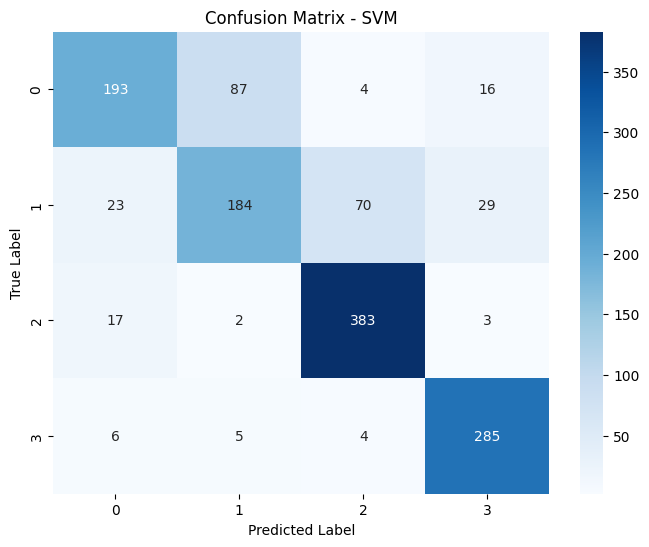


Training Neural Network...

Neural Network Results:
Accuracy: 0.9397

Classification Report:
              precision    recall  f1-score   support

      glioma       0.96      0.80      0.88       300
  meningioma       0.85      0.94      0.89       306
     notumor       0.98      1.00      0.99       405
   pituitary       0.96      0.99      0.98       300

    accuracy                           0.94      1311
   macro avg       0.94      0.93      0.93      1311
weighted avg       0.94      0.94      0.94      1311



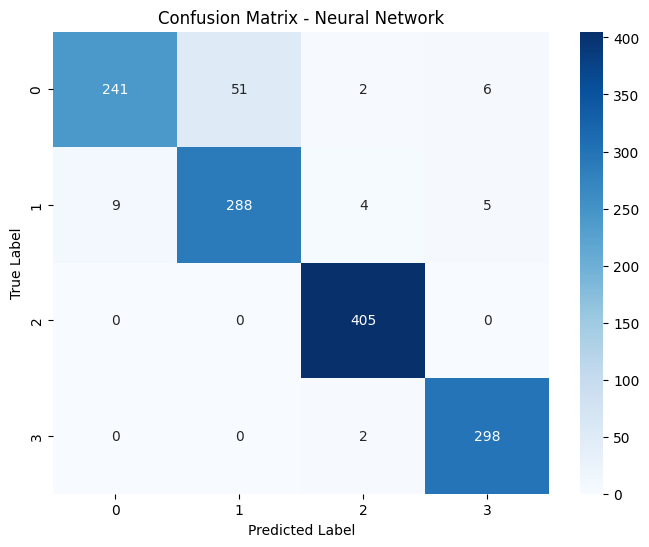

In [ ]:
#Train and Evaluate Models Function
def train_and_evaluate_models(X_train, X_test, y_train, y_test):
    # Initialize models
    models = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
        'SVM': SVC(kernel='rbf', probability=True, random_state=42),
        'Neural Network': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
    }
    
    results = {}
    
    # Train and evaluate each model
    for name, model in models.items():
        print(f"\nTraining {name}...")
        
        # Train model
        model.fit(X_train, y_train)
        
        # Make predictions
        y_pred = model.predict(X_test)
        
        # Calculate accuracy
        accuracy = accuracy_score(y_test, y_pred)
        
        # Print classification report
        print(f"\n{name} Results:")
        print(f"Accuracy: {accuracy:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Store results
        results[name] = {
            'model': model,
            'accuracy': accuracy,
            'predictions': y_pred
        }
        
        # Plot confusion matrix
        plt.figure(figsize=(8, 6))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix - {name}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()
    
    return results

# Train and evaluate models
print("\nTraining and evaluating models...")
results = train_and_evaluate_models(X_train, X_test, y_train, y_test)

In [11]:
def save_best_model(results, output_dir='../models'):
    """Save the best performing model"""
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Find best model
    best_model_name = max(results.items(), key=lambda x: x[1]['accuracy'])[0]
    best_model = results[best_model_name]['model']
    
    # Save model
    model_path = os.path.join(output_dir, f'best_ml_model_{best_model_name.lower().replace(" ", "_")}.joblib')
    joblib.dump(best_model, model_path)
    print(f"\nBest model ({best_model_name}) saved to {model_path}")

# Save the best model
save_best_model(results)


Best model (Neural Network) saved to ../models/best_ml_model_neural_network.joblib
